# 一、注意力机制

## 1、demo实例

In [3]:
import pandas as pd
import numpy as np

text1 = "我喜欢的水果是橙子和苹果"
text2 = "相比苹果我更加喜欢国产的华为"

In [4]:
import spacy

nlp = spacy.load('zh_core_web_sm')

In [5]:
doc = nlp(text1)

In [6]:
doc

我喜欢的水果是橙子和苹果

In [7]:
emd_dim = 10

In [8]:
dics = {}
for token in doc:
    dics[token.text] = token.vector[:emd_dim]

In [9]:
dics

{'我': array([-1.3247752 , -1.6688755 ,  0.749357  ,  0.85941577, -0.22634244,
        -1.6708682 ,  0.03403366,  1.3765073 ,  0.6426276 ,  1.5576223 ],
       dtype=float32),
 '喜欢': array([-1.3703265 , -0.602875  ,  0.27408972, -0.38036662, -0.49761173,
         0.2031984 , -0.12960458,  0.06462534, -0.42095014, -1.2041767 ],
       dtype=float32),
 '的': array([ 0.3415377 ,  0.6000297 , -1.7239015 , -0.72851676,  1.158524  ,
        -0.8583722 ,  1.2634337 ,  1.0109317 , -1.2898558 , -0.7436571 ],
       dtype=float32),
 '水果': array([-0.55852985, -0.20032012, -0.02420026, -0.04010248, -1.3015743 ,
        -1.3204076 , -0.7861524 ,  0.6362343 , -0.4448657 , -0.212     ],
       dtype=float32),
 '是': array([-0.6271794 , -1.6988527 ,  0.14448899,  2.466194  , -0.0993486 ,
        -0.3760319 ,  2.6196754 ,  0.55159503, -0.42107442,  1.0068394 ],
       dtype=float32),
 '橙子': array([ 1.0784352 , -0.7324965 ,  0.591076  , -0.20984882, -0.07178144,
         1.7195933 , -0.29536748, -0.1544032

In [10]:
len(dics['和'])

10

In [11]:
X = pd.DataFrame(dics)

In [12]:
X.T

,0,1,2,3,4,5,6,7,8,9
我,-1.324775,-1.668875,0.749357,0.859416,-0.226342,-1.670868,0.034034,1.376507,0.642628,1.557622
喜欢,-1.370327,-0.602875,0.274090,-0.380367,-0.497612,0.203198,-0.129605,0.064625,-0.420950,-1.204177
的,0.341538,0.600030,-1.723902,-0.728517,1.158524,-0.858372,1.263434,1.010932,-1.289856,-0.743657
水果,-0.558530,-0.200320,-0.024200,-0.040102,-1.301574,-1.320408,-0.786152,0.636234,-0.444866,-0.212000
是,-0.627179,-1.698853,0.144489,2.466194,-0.099349,-0.376032,2.619675,0.551595,-0.421074,1.006839
橙子,1.078435,-0.732497,0.591076,-0.209849,-0.071781,1.719593,-0.295367,-0.154403,0.773509,-1.587893
和,0.322416,2.647843,2.612501,0.236240,0.500240,0.762496,3.632153,1.523306,0.669406,2.868554
苹果,0.628400,-0.493155,1.145407,-0.822133,-0.707903,-0.963297,0.743129,0.423888,-0.995425,0.157017


## 2、初始化$W_q$,$W_k$,$W_v$

为了创建查询矩阵、键矩阵和值矩阵，我们需要先创建另外三个权重矩阵，分别为$W^Q 、W^K、W^V$。用矩阵X分别乘以矩阵$W^Q 、W^K、W^V$，就可以依次创建出查询矩阵Q、键矩阵K和值矩阵V。

In [13]:
emd_dim, d_k = 10, 6       # QKV向量的维度

$$Attention(Q,K,V) = softmax(\frac{QK^{T}}{\sqrt{d_k}})V$$

In [14]:
Wq = np.random.randn(emd_dim, d_k)

In [15]:
print(Wq)

[[ 1.67723544  0.26887837  0.65648733  0.69776757  0.57807699  1.93919168]
 [-0.34550484  0.31842356 -1.1140977  -0.18664367  1.03963587 -0.50299159]
 [-2.21716767 -2.12726282 -0.13468997 -0.75302241 -0.79079278  0.50601023]
 [ 1.66688449  0.39857526  1.55924576 -0.11859134 -0.60186462 -1.3338572 ]
 [ 0.86135088 -1.73017329  1.77855036  0.10582446 -0.8030504   0.85933928]
 [-1.38146209 -0.8353161  -0.77529938 -0.48538724  0.37218232  0.6862188 ]
 [ 0.04556462  0.34993629  1.08515745 -0.45387809  0.87233197  1.50319455]
 [-0.16644206 -1.03852274  1.09090838  1.14181905 -0.31216908  0.31218022]
 [ 0.3699261  -0.32198302  1.30143319  0.41466805  0.56772597  0.32538471]
 [ 0.60425985 -0.0733109  -1.80806686 -0.23384525 -1.26705732  0.91023297]]


In [16]:
Wk = np.random.randn(emd_dim, d_k)
Wv = np.random.randn(emd_dim, d_k)

## 3、计算得到QKV矩阵

In [17]:
X.T.shape

(8, 10)

In [18]:
Wq

array([[ 1.67723544,  0.26887837,  0.65648733,  0.69776757,  0.57807699,
         1.93919168],
       [-0.34550484,  0.31842356, -1.1140977 , -0.18664367,  1.03963587,
        -0.50299159],
       [-2.21716767, -2.12726282, -0.13468997, -0.75302241, -0.79079278,
         0.50601023],
       [ 1.66688449,  0.39857526,  1.55924576, -0.11859134, -0.60186462,
        -1.3338572 ],
       [ 0.86135088, -1.73017329,  1.77855036,  0.10582446, -0.8030504 ,
         0.85933928],
       [-1.38146209, -0.8353161 , -0.77529938, -0.48538724,  0.37218232,
         0.6862188 ],
       [ 0.04556462,  0.34993629,  1.08515745, -0.45387809,  0.87233197,
         1.50319455],
       [-0.16644206, -1.03852274,  1.09090838,  1.14181905, -0.31216908,
         0.31218022],
       [ 0.3699261 , -0.32198302,  1.30143319,  0.41466805,  0.56772597,
         0.32538471],
       [ 0.60425985, -0.0733109 , -1.80806686, -0.23384525, -1.26705732,
         0.91023297]])

In [19]:
np.dot(X.T, Wq)

array([[ 1.19039745, -2.09056572,  2.68019009,  0.96647316, -6.05956085,
        -1.73002652],
       [-4.94114108, -0.49251688, -0.34125727, -0.91657199,  0.22203476,
        -3.40391469],
       [ 4.11984861,  2.23435886,  3.51774679,  2.26999243,  2.36966419,
         1.98463571],
       [-0.61217121,  2.39937422, -1.84864466,  1.1221996 , -0.80240638,
        -4.28651637],
       [ 4.23962031,  0.85764595,  6.49780124, -1.31905273, -3.18923475,
         0.96796171],
       [-2.69693729, -2.67215599,  3.04509486,  0.27657198,  2.46005148,
         2.47120276],
       [-4.50218437, -6.7727181 , -1.13538216, -2.88411918,  0.05144341,
        10.0175857 ],
       [-2.27463851, -0.59405103, -1.29696006, -0.14461414, -0.59859168,
         2.94189956]])

In [20]:
X.T @  Wq

,0,1,2,3,4,5
我,1.190397,-2.090566,2.680190,0.966473,-6.059561,-1.730027
喜欢,-4.941141,-0.492517,-0.341257,-0.916572,0.222035,-3.403915
的,4.119849,2.234359,3.517747,2.269992,2.369664,1.984636
水果,-0.612171,2.399374,-1.848645,1.122200,-0.802406,-4.286516
是,4.239620,0.857646,6.497801,-1.319053,-3.189235,0.967962
橙子,-2.696937,-2.672156,3.045095,0.276572,2.460051,2.471203
和,-4.502184,-6.772718,-1.135382,-2.884119,0.051443,10.017586
苹果,-2.274639,-0.594051,-1.296960,-0.144614,-0.598592,2.941900


In [21]:
Q = X.T @  Wq

In [22]:
print(Q)

           0         1         2         3         4          5
我   1.190397 -2.090566  2.680190  0.966473 -6.059561  -1.730027
喜欢 -4.941141 -0.492517 -0.341257 -0.916572  0.222035  -3.403915
的   4.119849  2.234359  3.517747  2.269992  2.369664   1.984636
水果 -0.612171  2.399374 -1.848645  1.122200 -0.802406  -4.286516
是   4.239620  0.857646  6.497801 -1.319053 -3.189235   0.967962
橙子 -2.696937 -2.672156  3.045095  0.276572  2.460051   2.471203
和  -4.502184 -6.772718 -1.135382 -2.884119  0.051443  10.017586
苹果 -2.274639 -0.594051 -1.296960 -0.144614 -0.598592   2.941900


In [23]:
Q

,0,1,2,3,4,5
我,1.190397,-2.090566,2.680190,0.966473,-6.059561,-1.730027
喜欢,-4.941141,-0.492517,-0.341257,-0.916572,0.222035,-3.403915
的,4.119849,2.234359,3.517747,2.269992,2.369664,1.984636
水果,-0.612171,2.399374,-1.848645,1.122200,-0.802406,-4.286516
是,4.239620,0.857646,6.497801,-1.319053,-3.189235,0.967962
橙子,-2.696937,-2.672156,3.045095,0.276572,2.460051,2.471203
和,-4.502184,-6.772718,-1.135382,-2.884119,0.051443,10.017586
苹果,-2.274639,-0.594051,-1.296960,-0.144614,-0.598592,2.941900


In [24]:
K =  X.T @  Wk
V =  X.T @  Wv

## 4、相似矩阵

In [25]:
Q@K.T

,我,喜欢,的,水果,是,橙子,和,苹果
我,4.284287,10.120205,3.599544,34.924807,-15.270213,-3.614432,-38.343020,25.577054
喜欢,-26.731706,2.213986,2.310614,-28.312570,10.962264,-16.148277,39.263193,-31.352852
的,28.738132,11.381446,-7.129631,27.561979,-17.847101,10.218258,-66.897447,11.600978
水果,11.956678,-5.082034,3.387144,-17.785251,35.474018,-22.296532,26.499304,-28.672110
是,25.480362,30.999616,2.438864,59.335257,-59.318405,6.568011,-109.930188,28.810741
橙子,-29.553422,8.774195,-6.387837,1.804562,-28.216163,14.353108,-13.286317,8.337385
和,-55.670431,-11.914554,10.120539,9.028547,-42.272605,34.089538,26.416795,58.243339
苹果,-10.662131,-7.649063,12.149143,1.678373,1.347103,-1.017491,15.679628,13.547945


## 5、 点积缩放

In [26]:
Q@K.T/ np.sqrt(d_k)

,我,喜欢,的,水果,是,橙子,和,苹果
我,1.749053,4.131556,1.469508,14.257993,-6.234038,-1.475586,-15.653472,10.441789
喜欢,-10.913173,0.903856,0.943304,-11.558558,4.475326,-6.592506,16.029131,-12.799748
的,11.732293,4.646456,-2.910660,11.252131,-7.286048,4.171586,-27.310768,4.736079
水果,4.881293,-2.074732,1.382796,-7.260798,14.482207,-9.102521,10.818296,-11.705340
是,10.402314,12.655540,0.995662,24.223517,-24.216637,2.681379,-44.878811,11.761936
橙子,-12.065134,3.582050,-2.607824,0.736709,-11.519200,5.859632,-5.424116,3.403723
和,-22.727358,-4.864096,4.131693,3.685889,-17.257719,13.916995,10.784611,23.777743
苹果,-4.352797,-3.122717,4.959867,0.685193,0.549953,-0.415389,6.401181,5.530926


In [27]:
df_QK = Q@K.T/ np.sqrt(d_k)

## 6、 SoftMax

In [28]:
df_QK.iloc[0]

我      1.749053
喜欢     4.131556
的      1.469508
水果    14.257993
是     -6.234038
橙子    -1.475586
和    -15.653472
苹果    10.441789
Name: 我, dtype: float64

In [29]:
# 计算Softmax
for i in range(len(df_QK)):
    exp_v = np.exp(df_QK.iloc[i])
    softmax = exp_v / np.sum(exp_v)
    df_QK.iloc[i] = np.round(softmax, 4)

In [30]:
print(df_QK)

         我      喜欢       的      水果       是      橙子       和      苹果
我   0.0000  0.0000  0.0000  0.9784  0.0000  0.0000  0.0000  0.0215
喜欢  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  1.0000  0.0000
的   0.6169  0.0005  0.0000  0.3817  0.0000  0.0003  0.0000  0.0006
水果  0.0001  0.0000  0.0000  0.0000  0.9749  0.0000  0.0250  0.0000
是   0.0000  0.0000  0.0000  1.0000  0.0000  0.0000  0.0000  0.0000
橙子  0.0000  0.0858  0.0002  0.0050  0.0000  0.8372  0.0000  0.0718
和   0.0000  0.0000  0.0000  0.0000  0.0000  0.0001  0.0000  0.9999
苹果  0.0000  0.0000  0.1423  0.0020  0.0017  0.0007  0.6014  0.2519


## 7、V矩阵

In [31]:
V

,0,1,2,3,4,5
我,1.945410,-1.634472,2.121080,-5.342535,-0.991248,-0.058936
喜欢,-3.733024,-0.602856,-4.125245,-0.546453,1.482537,-3.163766
的,1.604667,2.785918,3.473066,2.798413,-0.362347,-4.651310
水果,-5.641122,0.723826,1.977798,-1.329313,-2.637475,2.007496
是,9.350047,-0.267819,1.663482,-4.638648,2.989194,-1.084779
橙子,0.678466,-0.852103,-5.407657,3.284911,-1.009315,-0.566582
和,17.682719,0.687203,8.852538,-1.102489,9.568227,5.156021
苹果,0.025658,0.275423,4.421526,-0.665132,2.947056,0.241176


In [32]:
attention = df_QK @V

In [33]:
print(attention)

            0         1         2         3         4         5
我   -5.518722  0.714113  2.030140 -1.314900 -2.517144  1.969319
喜欢  17.682719  0.687203  8.852538 -1.102489  9.568227  5.156021
的   -0.954740 -0.732413  2.062388 -3.802896 -1.616019  0.728296
水果   9.557624 -0.244080  1.843255 -4.550315  3.153272 -0.928657
是   -5.641122  0.723826  1.977798 -1.329313 -2.637475  2.007496
橙子   0.221676 -0.741154 -4.553187  2.649398 -0.519458 -0.719370
和    0.025723  0.275310  4.420544 -0.664737  2.946660  0.241095
苹果  10.874282  0.879495  6.934914 -0.440614  6.444233  2.501476


# 二、多头注意力机制

## 2.1  定义多头注意力机制的参数

In [34]:
# 注意力头的数量
num_heads = 8  # 例如使用8个头

# 假设d_k是每个头的维度，总的嵌入维度应为num_heads * d_k
embed_size = d_k * num_heads

# 为多个头初始化权重矩阵
Wq_multi = [np.random.randn(emd_dim, d_k) for _ in range(num_heads)]
Wk_multi = [np.random.randn(emd_dim, d_k) for _ in range(num_heads)]
Wv_multi = [np.random.randn(emd_dim, d_k) for _ in range(num_heads)]


In [40]:
for i, Wq in enumerate(Wq_multi):
    print(f"Head {i+1} shape: {Wq.shape}")

Head 1 shape: (10, 6)
Head 2 shape: (10, 6)
Head 3 shape: (10, 6)
Head 4 shape: (10, 6)
Head 5 shape: (10, 6)
Head 6 shape: (10, 6)
Head 7 shape: (10, 6)
Head 8 shape: (10, 6)


In [38]:
Wq_multi[0].shape  # 查看第一个矩阵的形状

(10, 6)

## 2.2 为每个头应用线性变换

In [41]:
queries = [np.dot(X.T, Wq) for Wq in Wq_multi]
keys = [np.dot(X.T, Wk) for Wk in Wk_multi]
values = [np.dot(X.T, Wv) for Wv in Wv_multi]


In [59]:
print(queries[0].shape, keys[0].shape)

(8, 6) (8, 6)


## 2.3 计算每个头的缩放点积注意力

In [47]:
def scaled_dot_product_attention(Q, K, V, d_k):
    # 计算queries和keys之间的点积并进行缩放
    scores = np.dot(Q, K.T) / np.sqrt(d_k)
    # 对分数应用softmax，得到注意力权重
    attention_weights = np.exp(scores) / np.sum(np.exp(scores), axis=-1, keepdims=True)
    # 使用注意力权重乘以values
    return np.dot(attention_weights, V)

attention_heads = [scaled_dot_product_attention(Q, K, V, d_k) for Q, K, V in zip(queries, keys, values)]


In [60]:
print(attention_heads[0].shape)

(8, 6)


## 2.4 拼接所有头的输出

In [51]:
# 沿着最后一个维度拼接所有注意力头的输出
multi_head_attention = np.concatenate(attention_heads, axis=-1)


In [54]:
multi_head_attention.shape

(8, 48)

## 2.5 线性变换

In [57]:
# 初始化最后线性变换的权重矩阵
W_out = np.random.randn(embed_size, emd_dim)

# 应用最后的线性变换
output = np.dot(multi_head_attention, W_out)


In [62]:
output.shape

(8, 10)

# 三、位置编码

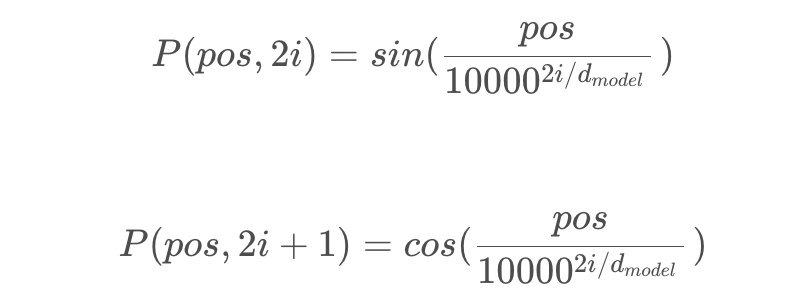

In [64]:
from IPython.display import (Image) 
Image(filename="..\sincos.png",width=400,height=400)

In [65]:
X.T

,0,1,2,3,4,5,6,7,8,9
我,-1.324775,-1.668875,0.749357,0.859416,-0.226342,-1.670868,0.034034,1.376507,0.642628,1.557622
喜欢,-1.370327,-0.602875,0.274090,-0.380367,-0.497612,0.203198,-0.129605,0.064625,-0.420950,-1.204177
的,0.341538,0.600030,-1.723902,-0.728517,1.158524,-0.858372,1.263434,1.010932,-1.289856,-0.743657
水果,-0.558530,-0.200320,-0.024200,-0.040102,-1.301574,-1.320408,-0.786152,0.636234,-0.444866,-0.212000
是,-0.627179,-1.698853,0.144489,2.466194,-0.099349,-0.376032,2.619675,0.551595,-0.421074,1.006839
橙子,1.078435,-0.732497,0.591076,-0.209849,-0.071781,1.719593,-0.295367,-0.154403,0.773509,-1.587893
和,0.322416,2.647843,2.612501,0.236240,0.500240,0.762496,3.632153,1.523306,0.669406,2.868554
苹果,0.628400,-0.493155,1.145407,-0.822133,-0.707903,-0.963297,0.743129,0.423888,-0.995425,0.157017


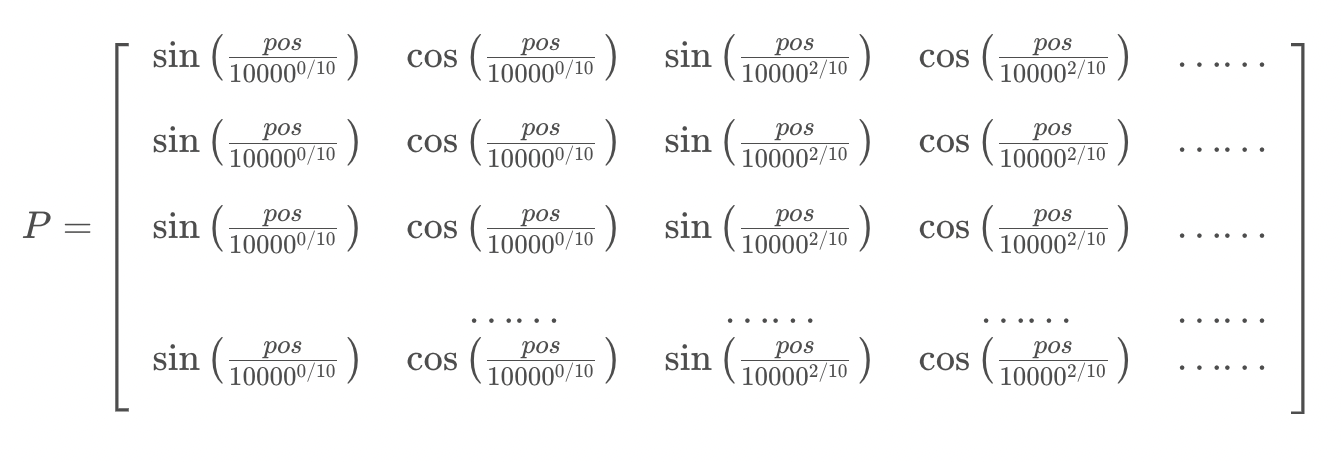

In [67]:
from IPython.display import (Image)
Image(filename="..\sin.png",width=400,height=400)

In [87]:
pos ,d_model= 8, 10
pos_encoding = np.zeros((pos, d_model))
pos_encoding

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [88]:
# 获取位置索引，并扩展维度以进行计算
position = np.arange(pos)[:, np.newaxis]
print(position)

[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]]


In [89]:
np.arange(pos)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [90]:
# 计算分母中的项
div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
div_term

array([1.00000000e+00, 1.58489319e-01, 2.51188643e-02, 3.98107171e-03,
       6.30957344e-04])

In [91]:
1/np.power(10000,0.2)  

0.15848931924611132

In [92]:
# 将正弦应用于偶数索引
pos_encoding[:, 0::2] = np.sin(position * div_term)
pos_encoding

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 8.41470985e-01,  0.00000000e+00,  1.57826640e-01,
         0.00000000e+00,  2.51162229e-02,  0.00000000e+00,
         3.98106119e-03,  0.00000000e+00,  6.30957303e-04,
         0.00000000e+00],
       [ 9.09297427e-01,  0.00000000e+00,  3.11697146e-01,
         0.00000000e+00,  5.02165994e-02,  0.00000000e+00,
         7.96205928e-03,  0.00000000e+00,  1.26191435e-03,
         0.00000000e+00],
       [ 1.41120008e-01,  0.00000000e+00,  4.57754548e-01,
         0.00000000e+00,  7.52852930e-02,  0.00000000e+00,
         1.19429312e-02,  0.00000000e+00,  1.89287090e-03,
         0.00000000e+00],
       [-7.56802495e-01,  0.00000000e+00,  5.92337725e-01,
         0.00000000e+00,  1.00306487e-01,  0.00000000e+00,
         1.59236138e-02,  0.00000000e+00,  2.52382670e-03,
         0.

In [93]:
# 将余弦应用于奇数索引
pos_encoding[:, 1::2] = np.cos(position * div_term)

In [95]:
print(pos_encoding)

[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  1.57826640e-01  9.87466836e-01
   2.51162229e-02  9.99684538e-01  3.98106119e-03  9.99992076e-01
   6.30957303e-04  9.99999801e-01]
 [ 9.09297427e-01 -4.16146837e-01  3.11697146e-01  9.50181503e-01
   5.02165994e-02  9.98738351e-01  7.96205928e-03  9.99968302e-01
   1.26191435e-03  9.99999204e-01]
 [ 1.41120008e-01 -9.89992497e-01  4.57754548e-01  8.89078609e-01
   7.52852930e-02  9.97162035e-01  1.19429312e-02  9.99928681e-01
   1.89287090e-03  9.99998209e-01]
 [-7.56802495e-01 -6.53643621e-01  5.92337725e-01  8.05689779e-01
   1.00306487e-01  9.94956586e-01  1.59236138e-02  9.99873211e-01
   2.52382670e-03  9.99996815e-01]
 [-9.58924275e-01  2.83662185e-01  7.12073170e-01  7.02105263e-01
   1.25264396e-01  9.92123395e-01  1.99040441e-02  9.99801895e-01
   3.15478149e-03  9.99995024e-01

In [77]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(pos, d_model):
    """
    生成位置编码
    :param pos: 位置序号 (序列长度)
    :param d_model: 模型的维度
    :return: 位置编码矩阵 (pos, d_model)
    """
    # 初始化位置编码矩阵
    pos_encoding = np.zeros((pos, d_model))
    # 获取位置索引，并扩展维度以进行计算
    position = np.arange(pos)[:, np.newaxis]
    # 计算分母中的项
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    # 将正弦应用于偶数索引
    pos_encoding[:, 0::2] = np.sin(position * div_term)
    # 将余弦应用于奇数索引
    pos_encoding[:, 1::2] = np.cos(position * div_term)

    return pos_encoding



In [78]:
# 设置位置序号和模型的维度
pos = 100  # 序列长度
d_model = 16  # 模型的维度

# 生成位置编码
pos_encoding = positional_encoding(pos, d_model)

In [79]:
pos_encoding

array([[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00, ...,
         1.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 8.41470985e-01,  5.40302306e-01,  3.10983593e-01, ...,
         9.99999500e-01,  3.16227761e-04,  9.99999950e-01],
       [ 9.09297427e-01, -4.16146837e-01,  5.91127117e-01, ...,
         9.99998000e-01,  6.32455490e-04,  9.99999800e-01],
       ...,
       [ 3.79607739e-01, -9.25147537e-01, -6.75640562e-01, ...,
         9.95299188e-01,  3.06692833e-02,  9.99529587e-01],
       [-5.73381872e-01, -8.19288245e-01, -4.12872309e-01, ...,
         9.95201842e-01,  3.09853608e-02,  9.99519838e-01],
       [-9.99206834e-01,  3.98208804e-02, -1.09159741e-01, ...,
         9.95103501e-01,  3.13014352e-02,  9.99509990e-01]])

In [80]:
pos_encoding[:,2]

array([ 0.        ,  0.31098359,  0.59112712,  0.8126489 ,  0.95358074,
        0.99994652,  0.94714816,  0.80042165,  0.57431777,  0.29125912,
       -0.02068353, -0.33057501, -0.60768355, -0.82452845, -0.95960533,
       -0.99951869, -0.94031033, -0.78785193, -0.5572627 , -0.27141003,
        0.04135821,  0.35002499,  0.62397998,  0.83605523,  0.96521935,
        0.99866321,  0.93307019,  0.77494513,  0.5399692 ,  0.25144482,
       -0.0620152 , -0.36932521, -0.64000944, -0.8472243 , -0.97042039,
       -0.99738044, -0.92543083, -0.76170677, -0.52244467, -0.23137202,
        0.08264565,  0.38846741,  0.65576507,  0.85803087,  0.97520624,
        0.99567095,  0.91739553,  0.74814251,  0.50469661,  0.21120024,
       -0.10324075, -0.4074434 , -0.67124013, -0.86847034, -0.97957484,
       -0.99353545, -0.90896771, -0.73425815, -0.48673262, -0.19093809,
        0.12379167,  0.42624507,  0.68642799,  0.87853823,  0.98352433,
        0.99097487,  0.90015098,  0.72005963,  0.46856037,  0.17

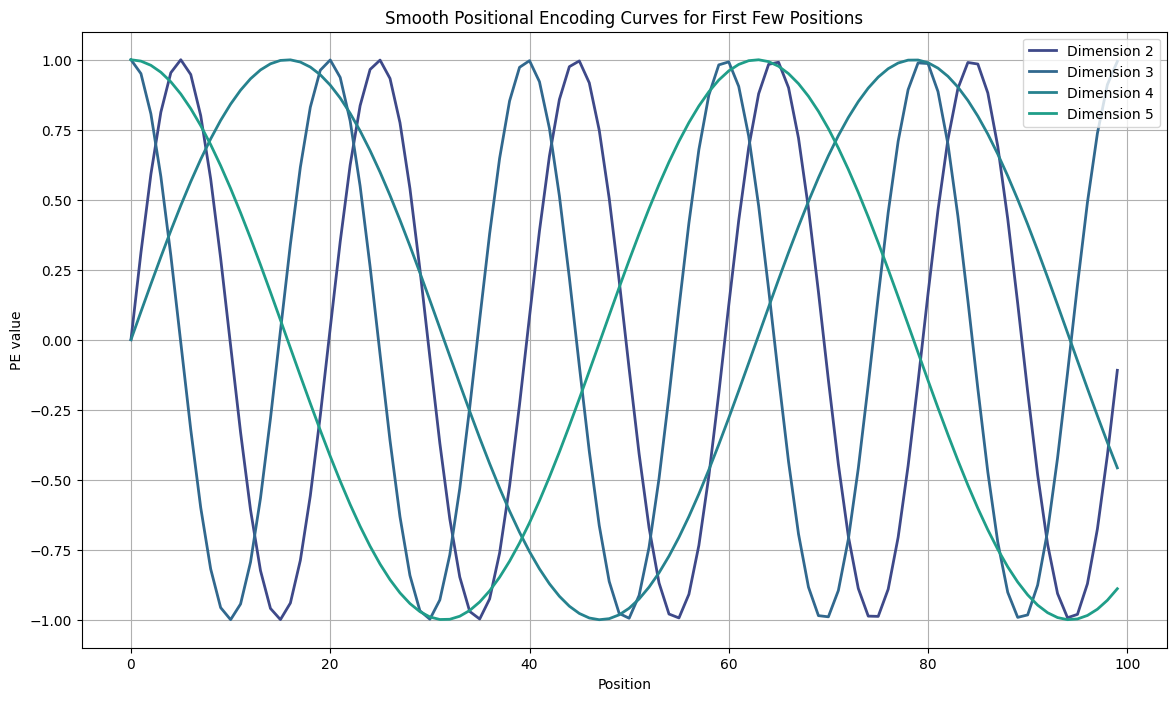

In [81]:
# 使用更圆滑的线条和不同的颜色绘制位置编码曲线图
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, min(pos, 10)))
for i in range(2,min(pos, 6)):  # 只展示前10个位置的编码
    plt.plot(pos_encoding[:,i], label=f'Dimension {i}', color=colors[i], linewidth=2, linestyle='-', marker='', markersize=6)
plt.xlabel('Position')
plt.ylabel('PE value')
plt.title('Smooth Positional Encoding Curves for First Few Positions')
plt.legend()
plt.grid(True)
plt.show()


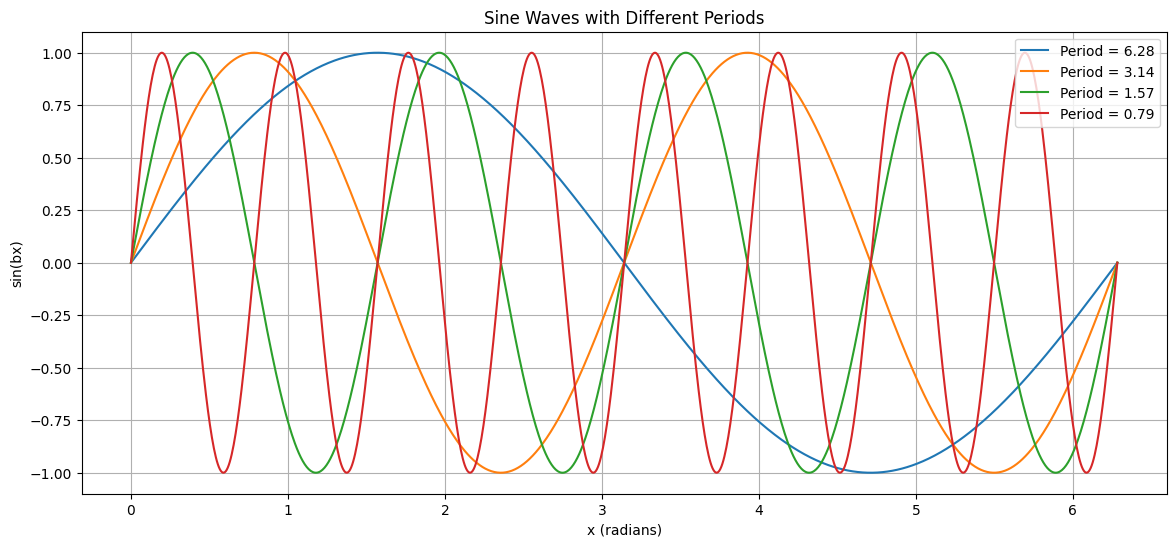

In [82]:
# 设置画布大小
plt.figure(figsize=(14, 6))

# 设置不同的周期参数 b
periods = [1, 2, 4, 8]
x = np.linspace(0, 2*np.pi, 1000)  # 从0到2pi生成1000个点

# 对于每个不同的周期参数 b，绘制一个正弦曲线
for b in periods:
    y = np.sin(b * x)
    plt.plot(x, y, label=f'Period = {2*np.pi/b:.2f}')

# 添加图例
plt.legend()
plt.title('Sine Waves with Different Periods')
plt.xlabel('x (radians)')
plt.ylabel('sin(bx)')
plt.grid(True)
plt.show()


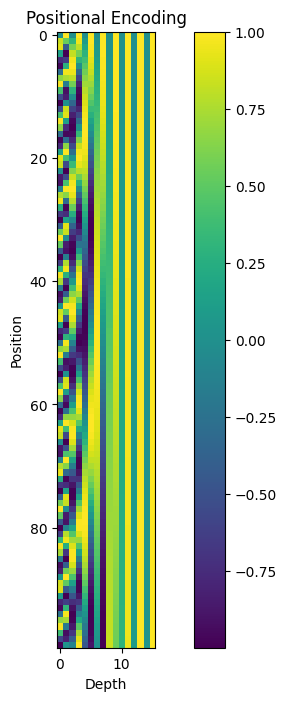

In [83]:



# 绘制位置编码图形
plt.figure(figsize=(10, 8))
plt.imshow(pos_encoding, cmap='viridis')
plt.colorbar()
plt.xlabel('Depth')
plt.ylabel('Position')
plt.title('Positional Encoding')
plt.grid(False)
plt.show()

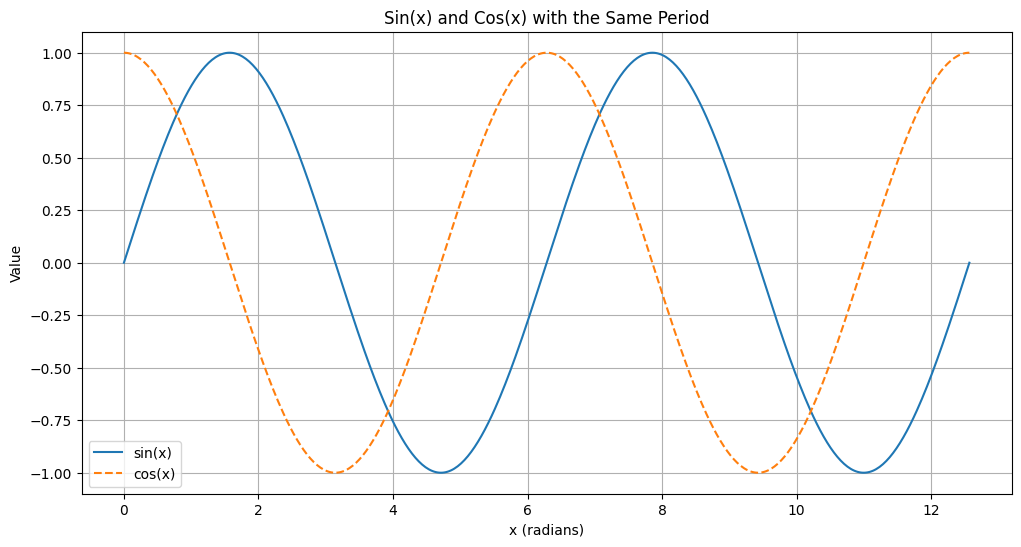

In [84]:
# Define the x range for the plot
x_values = np.linspace(0, 4 * np.pi, 500)  # 4 periods

# Calculate the y values for sin and cos functions
sin_values = np.sin(x_values)
cos_values = np.cos(x_values)

# Plotting sin(x) and cos(x)
plt.figure(figsize=(12, 6))
plt.plot(x_values, sin_values, label='sin(x)')
plt.plot(x_values, cos_values, label='cos(x)', linestyle='--')

# Adding titles and labels
plt.title('Sin(x) and Cos(x) with the Same Period')
plt.xlabel('x (radians)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


# 四、前馈网络层

In [105]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNetwork(nn.Module):
    def __init__(self, d_model, d_ff):
        super(FeedForwardNetwork, self).__init__()
        # 第一个全连接层，映射到更高维度 d_ff
        self.fc1 = nn.Linear(d_model, d_ff)
        # 第二个全连接层，将高维度映射回 d_model
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, X ):
        # 前向传播，首先通过ReLU激活函数，随后通过第二个全连接层
        X = F.relu(self.fc1(X ))
        X = self.fc2(X)
        return X

In [102]:
d_ff = 16  # 中间层的维度
ffn = FeedForwardNetwork(d_model, d_ff)

In [112]:
output = torch.from_numpy(output).float()
output = ffn(output)
print(output.shape)  # 输出的形状应为 (8,10)

torch.Size([8, 10])


# 五、解码器

## 5.1 掩码注意力机制

In [47]:
import spacy
import pandas as pd

# 加载SpaCy的中文模型
nlp = spacy.load('zh_core_web_sm')

# 定义文本和开始符
text_en = "sos I love China"

# 创建Spacy文档对象
doc = nlp(text_en)

# 初始化字典和向量维度
dics = {}
emd_dim = 10

# 遍历Spacy的tokens，并将其向量存储在字典中
for token in doc:
    dics[token.text] = token.vector[:emd_dim]  # 如果你只想使用向量的前10维




In [48]:
# 打印结果
for key, value in dics.items():
    print(f"{key}: {value}")

sos: [-0.17680249 -0.89726907 -0.05940163 -0.8247601  -0.77933216 -1.6954485
  1.2723771  -2.7441187   0.92058736 -0.37640035]
I: [-0.08821413 -0.94260186 -0.04452944  0.7513809   0.0378975  -0.88159305
 -0.01694727  0.79611933  1.4401363   0.4629683 ]
love: [-0.5379796  -0.35040748 -0.0640732  -0.85832727  1.2782278  -0.62840176
  0.8343049  -1.7030168   0.24678701 -2.3284369 ]
China: [ 0.47836018 -0.47081274 -0.55481744  1.5058193  -0.534563    1.827565
  1.9101998  -0.67563295  1.0628512  -0.85532606]


In [49]:
X = pd.DataFrame(dics).T

In [50]:
X 

,0,1,2,3,4,5,6,7,8,9
sos,-0.176802,-0.897269,-0.059402,-0.824760,-0.779332,-1.695449,1.272377,-2.744119,0.920587,-0.376400
I,-0.088214,-0.942602,-0.044529,0.751381,0.037897,-0.881593,-0.016947,0.796119,1.440136,0.462968
love,-0.537980,-0.350407,-0.064073,-0.858327,1.278228,-0.628402,0.834305,-1.703017,0.246787,-2.328437
China,0.478360,-0.470813,-0.554817,1.505819,-0.534563,1.827565,1.910200,-0.675633,1.062851,-0.855326


In [66]:
emd_dim, d_k = 10, 6       # QKV向量的维度

Wq = np.random.randn(emd_dim, d_k)
Wk = np.random.randn(emd_dim, d_k)
Wv = np.random.randn(emd_dim, d_k)

In [67]:
Q =  X @  Wq
K =  X @  Wk
V =  X @  Wv

In [68]:
Q

,0,1,2,3,4,5
sos,4.885180,1.001855,4.145160,-1.897595,4.834130,3.936303
I,-3.971045,0.812809,0.768919,2.584540,2.874625,1.555942
love,2.689806,-0.063373,2.845299,-8.185266,2.899619,2.647321
China,-3.619334,0.983481,2.407783,-0.589770,6.496196,-4.743378


In [92]:
QKT = Q@K.T

In [93]:
print(QKT)

             sos          I       love      China
sos   -33.216338 -23.967733 -16.745646 -48.127223
I       3.662955  21.006677  -8.159184  22.436083
love  -32.606001 -13.229870 -25.590892 -97.620361
China   2.462841   2.671438   6.871162  -1.412900


numpy实现掩码

In [94]:
mask = np.triu(np.ones(QKT.shape), k=1)
mask

array([[0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [95]:
QKT += (mask * -1e9)  # Apply a large negative number to masked positions
QKT

,sos,I,love,China
sos,-33.216338,-1.000000e+09,-1.000000e+09,-1.000000e+09
I,3.662955,2.100668e+01,-1.000000e+09,-1.000000e+09
love,-32.606001,-1.322987e+01,-2.559089e+01,-1.000000e+09
China,2.462841,2.671438e+00,6.871162e+00,-1.412900e+00


In [96]:
print(QKT)

             sos             I          love         China
sos   -33.216338 -1.000000e+09 -1.000000e+09 -1.000000e+09
I       3.662955  2.100668e+01 -1.000000e+09 -1.000000e+09
love  -32.606001 -1.322987e+01 -2.559089e+01 -1.000000e+09
China   2.462841  2.671438e+00  6.871162e+00 -1.412900e+00


In [97]:
# 计算Softmax
for i in range(len(QKT)):
    exp_v = np.exp(QKT.iloc[i])
    softmax = exp_v / np.sum(exp_v)
    QKT.iloc[i] = np.round(softmax, 6)

In [98]:
print(QKT)

            sos         I      love     China
sos    1.000000  0.000000  0.000000  0.000000
I      0.000000  1.000000  0.000000  0.000000
love   0.000000  0.999996  0.000004  0.000000
China  0.011851  0.014599  0.973304  0.000246


: 

pytorch实现掩码

In [46]:
import torch

mask = torch.tril(torch.ones(QKT.shape))
mask

tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

In [16]:
QKT_tensor = torch.from_numpy(QKT.values)
QKT_tensor

tensor([[ -0.2262,   2.1826,   9.0939, -14.6615],
        [  0.6811,   5.5400, -22.8857,  42.3418],
        [ -8.2466,  -4.1692, -17.4612,  13.8717],
        [-28.3475,   4.5780, -21.4049, -52.9676]], dtype=torch.float64)

In [17]:
QKT_attention = QKT_tensor.masked_fill(mask==0, -torch.inf)
QKT_attention

tensor([[ -0.2262,     -inf,     -inf,     -inf],
        [  0.6811,   5.5400,     -inf,     -inf],
        [ -8.2466,  -4.1692, -17.4612,     -inf],
        [-28.3475,   4.5780, -21.4049, -52.9676]], dtype=torch.float64)

In [18]:
QKT_attention = torch.softmax(QKT_attention, dim=-1)

In [19]:
QKT_attention

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [7.6988e-03, 9.9230e-01, 0.0000e+00, 0.0000e+00],
        [1.6670e-02, 9.8333e-01, 1.6598e-06, 0.0000e+00],
        [5.0190e-15, 1.0000e+00, 5.1970e-12, 1.0192e-25]], dtype=torch.float64)

In [26]:
attention = QKT_attention@V
attention

,0,1,2,3,4,5
0,1.866582,0.703130,4.608560,-3.446458,3.092803,1.611515
1,-0.497975,4.845329,-2.456351,-0.551845,1.362921,-1.666920
2,-0.476596,4.807868,-2.392470,-0.578014,1.378558,-1.637273
3,-0.516321,4.877466,-2.511164,-0.529387,1.349499,-1.692356


In [28]:
attention.index =  ["<sos>", "you", "like", "swiming"]
attention

,0,1,2,3,4,5
<sos>,1.866582,0.703130,4.608560,-3.446458,3.092803,1.611515
you,-0.497975,4.845329,-2.456351,-0.551845,1.362921,-1.666920
like,-0.476596,4.807868,-2.392470,-0.578014,1.378558,-1.637273
swiming,-0.516321,4.877466,-2.511164,-0.529387,1.349499,-1.692356


## 5.2 交互式注意力机制

In [11]:
import spacy
import pandas as pd

emd_dim, d_k = 10, 6       # QKV向量的维度

# 加载SpaCy的中文模型
nlp = spacy.load('zh_core_web_sm')

# 定义文本和开始符
text_zh = "我喜欢中国"
text_en = "sos I love China"

# 创建Spacy文档对象
doc_zh = nlp(text_zh)
doc_en = nlp(text_en)

# 初始化字典和向量维度
dics_zh = {}
dics_en = {}
emd_dim = 10

# 遍历Spacy的tokens，并将其向量存储在字典中
for token in doc_zh:
    dics_zh[token.text] = token.vector[:emd_dim]  # 如果你只想使用向量的前10维
encode_output = pd.DataFrame(dics_zh).T

for token in doc_en:
    dics_en[token.text] = token.vector[:emd_dim]  # 如果你只想使用向量的前10维
decode_input = pd.DataFrame(dics_en).T

In [12]:
encode_output

,0,1,2,3,4,5,6,7,8,9
我,-1.769336,-2.091174,1.371328,1.012869,0.006651,-1.867824,0.145265,1.700134,0.411260,1.826702
喜欢,0.205299,-1.465050,0.104574,-1.044636,-0.473869,0.839470,-0.051560,0.693983,-0.029806,-0.660305
中国,-0.772062,-1.904786,1.347866,-0.383598,-0.243421,0.281965,3.738664,-0.864947,-0.569085,-0.366133


In [13]:
decode_input

,0,1,2,3,4,5,6,7,8,9
sos,-0.176802,-0.897269,-0.059402,-0.824760,-0.779332,-1.695449,1.272377,-2.744119,0.920587,-0.376400
I,-0.088214,-0.942602,-0.044529,0.751381,0.037897,-0.881593,-0.016947,0.796119,1.440136,0.462968
love,-0.537980,-0.350407,-0.064073,-0.858327,1.278228,-0.628402,0.834305,-1.703017,0.246787,-2.328437
China,0.478360,-0.470813,-0.554817,1.505819,-0.534563,1.827565,1.910200,-0.675633,1.062851,-0.855326


In [14]:
import numpy as np

Wq = np.random.randn(emd_dim, d_k)
Wk = np.random.randn(emd_dim, d_k)
Wv = np.random.randn(emd_dim, d_k)

Q =  decode_input  @  Wq
K =  encode_output @  Wk
V =  encode_output @  Wv

In [15]:
Q

,0,1,2,3,4,5
sos,-3.531603,4.587109,-0.165461,-3.551444,1.117569,-5.660329
I,2.564433,1.760677,1.421278,1.839837,-1.347925,-3.098078
love,-2.529545,4.766858,1.239474,-2.940616,3.548334,0.042696
China,3.394391,-1.847023,1.582371,-7.010835,7.735863,-6.410108


In [16]:
K

,0,1,2,3,4,5
我,-4.365287,-4.425975,3.320010,3.710602,2.410109,7.082546
喜欢,1.237889,1.426106,1.813198,-0.605699,-3.326096,-2.872162
中国,0.161291,-1.692111,-6.036928,2.581942,3.119707,1.948777


In [17]:
V

,0,1,2,3,4,5
我,0.556574,-0.387408,2.335216,-2.797853,-9.151225,-0.867749
喜欢,1.999854,-1.644072,-2.898936,-0.819533,2.253972,4.371753
中国,-2.681513,-6.492899,-3.721697,2.366969,0.000479,3.254952


In [18]:
Q,K,V

(              0         1         2         3         4         5
 sos   -3.531603  4.587109 -0.165461 -3.551444  1.117569 -5.660329
 I      2.564433  1.760677  1.421278  1.839837 -1.347925 -3.098078
 love  -2.529545  4.766858  1.239474 -2.940616  3.548334  0.042696
 China  3.394391 -1.847023  1.582371 -7.010835  7.735863 -6.410108,
            0         1         2         3         4         5
 我  -4.365287 -4.425975  3.320010  3.710602  2.410109  7.082546
 喜欢  1.237889  1.426106  1.813198 -0.605699 -3.326096 -2.872162
 中国  0.161291 -1.692111 -6.036928  2.581942  3.119707  1.948777,
            0         1         2         3         4         5
 我   0.556574 -0.387408  2.335216 -2.797853 -9.151225 -0.867749
 喜欢  1.999854 -1.644072 -2.898936 -0.819533  2.253972  4.371753
 中国 -2.681513 -6.492899 -3.721697  2.366969  0.000479  3.254952)

In [22]:
QKT = Q@K.T
print(QKT)

               我         喜欢         中国
sos   -56.009364  16.561303 -24.046482
I     -32.632560  20.529576 -16.638036
love   -7.997929  -4.229439 -12.396189
China -54.159152   1.364077 -12.339616


In [21]:
for i in range(len(QKT)):
    exp_v = np.exp(QKT.iloc[i])
    softmax = exp_v / np.sum(exp_v)
    QKT.iloc[i] = np.round(softmax, 6)
attention = QKT@V
attention

,0,1,2,3,4,5
sos,0.701786,-2.405404,-1.963980,-0.563470,-0.640876,3.024590
I,0.701786,-2.405404,-1.963980,-0.563470,-0.640876,3.024590
love,0.683856,-2.405785,-1.930861,-0.570831,-0.720285,2.987957
China,0.701786,-2.405404,-1.963980,-0.563470,-0.640876,3.024590


In [23]:
print(attention)

              0         1         2         3         4         5
sos    0.701786 -2.405404 -1.963980 -0.563470 -0.640876  3.024590
I      0.701786 -2.405404 -1.963980 -0.563470 -0.640876  3.024590
love   0.683856 -2.405785 -1.930861 -0.570831 -0.720285  2.987957
China  0.701786 -2.405404 -1.963980 -0.563470 -0.640876  3.024590
